In [113]:
import numpy as np
import pandas as pd
import scipy
import joblib
import matplotlib.pyplot as plt
from filterpy.kalman import predict, update
import warnings
warnings.filterwarnings("ignore")

## Kalman Filter Implementation with Raman and Dynamic Models

#### Design State Variable and State Covariance

In [69]:
# this is the intitial state vector with starting position and velocity
x = np.array([10.0, 4.5])
# this is the initial input to the system
u = np.array([2., 3.])
# This holds the σ^2/variance of the position and velocity
P = np.diag([100., 50.])

#### Design the Process Model

In [70]:
# this is basically the A matrix in state space form
F = np.array([[0.358 , 0.571 ],
       [0.0241, 0.532 ]])
# B matrix in state space form
B = np.array([[ 0.49  ,  0.107 ],
       [-0.0825,  0.307 ]])

In [71]:
# Q is the process noise
x, P = predict(x=x, P=P, F=F, Q=0, B=B, u=u)
print('x =', x)

x = [7.4505 3.391 ]


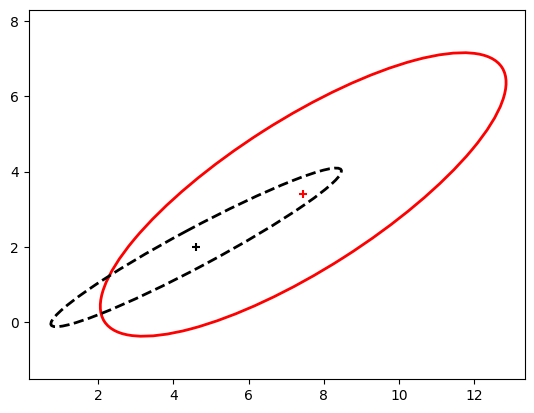

In [72]:
from filterpy.stats import plot_covariance_ellipse

plot_covariance_ellipse(x, P, edgecolor='r')
x, P = predict(x, P, F, Q=0)
plot_covariance_ellipse(x, P, edgecolor='k', ls='dashed')

#### Design the Process Noise

In [73]:
from filterpy.common import Q_discrete_white_noise
Q = Q_discrete_white_noise(dim=2, dt=1., var=2.35)

## Update Step

#### Design the Measurement Function

In [74]:
# This matrix is to convert our states to measurement space
# The function will be y = z - Hx, where z is the measurement from the raman sensor
# we will convert the VCC and glucose states to just glucose using the matrix below
# Then find the residual of the measurment - predicted
H = np.array([[0,1]])

#### Design the Measurement

In [75]:
# we only have one measurement from the raman so z is defined as
gluc = 0
z = np.array([[gluc]])
# two measurements would be defined as [z1, z2]

# Need to specify R which is a covariance matrix for the measurement noise defined 
# as an m x m matrix, with m as the number of sensors
R = np.array([[5.]])

In [76]:
from filterpy.kalman import update
z = 1.
x, P = update(x, P, z, R, H)
print('x =', x)

x = [3.78696815 1.52040273]


## Implementing the Kalman Filter

In [173]:
from filterpy.kalman import KalmanFilter
gluc_filter = KalmanFilter(dim_x=2, dim_z=1)
print('x = ', gluc_filter.x.T)
print('R = ', gluc_filter.R)
print('Q = \n', gluc_filter.Q)

x =  [[0. 0.]]
R =  [[1.]]
Q = 
 [[1. 0.]
 [0. 1.]]


In [5]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def gluc_filter(x, P, R, Q=0., dt=1.0):
    """ Returns a KalmanFilter which implements a
    constant velocity model for a state [x dx].T
    """
    
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.array([x[0], x[1]])           # location and velocity
    kf.F = np.array([[0.358, 0.571],
                     [0.0241, 0.532]])      # state transition matrix
    kf.B = np.array([[ 0.49  ,  0.107 ], 
                     [-0.0825,  0.307 ]])   # Input transition matrix
    kf.H = np.array([[0,1]])                # Measurement function
    kf.R *= R                               # measurement uncertainty
    if np.isscalar(P):
        kf.P *= P                           # covariance matrix 
    else:
        kf.P[:] = P                         # [:] makes deep copy
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    return kf

In [6]:
x = np.array([10.0, 4.5])
# this is the initial input to the system
u = np.array([2., 3.])
# This holds the σ^2/variance of the position and velocity
P = np.diag([100., 50.])
R = np.array([[5.]])

dt = 1
kf = gluc_filter(x, P=P, R=R, Q=0.1, dt=dt)

#### Clean data for Kalman Filter

In [3]:
dcs_data = pd.read_excel(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\DCS-Kalman-Filter-Data.xlsx",sheet_name="DCS_Data")
scaler_train = joblib.load(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\scaler_train.scale")
offline_data = pd.read_excel(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\DCS-Kalman-Filter-Data.xlsx", sheet_name="Offline_Data")
pd.DataFrame(index=scaler_train.feature_names_in_, data=scaler_train.scale_)

,0
Glucose Added (mL),0.059172
F30 Feed Amount (mL),0.016100
TCC,0.023093
Daily_Feed_Normalized,22.125556
Gluc,0.144300
IGG,0.000180
Daily_Glucose_Normalized,68.085185
VCC,0.015565
Ammonium,0.035063
Lact,0.120192


## Wuxi VCC and Glucose Models

#### Wuxi VCc Model from MR23-008

In [211]:
df_wuxi_offline = pd.read_excel(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\MR23-008-Kalman-Filter-Data.xlsx", sheet_name="AR22-092 Offline Data")
df_wuxi_offline_MR = pd.read_excel(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\MR23-008-Kalman-Filter-Data.xlsx", sheet_name="Offline Data")
df_wuxi_online = pd.read_excel(r"C:\Users\zah48132\OneDrive - GSK\Documents\GitHub\state-space-model\data\raw\MR23-008-Kalman-Filter-Data.xlsx", sheet_name="DCS Data")
df_wuxi_offline_MR.head()

,Datetime,Day,VCC-710,VCC-711,VCC-712,Gluc-710,Gluc-711,Gluc-712
0,2023-02-14 12:25:33,0,0.45,0.400,0.438,5.88,5.83,5.86
1,2023-02-15 11:21:43,1,1.39,0.997,1.060,5.32,5.50,5.34
2,2023-02-16 11:02:28,2,2.86,2.030,2.440,4.33,4.58,4.42
3,2023-02-17 11:35:47,3,6.41,5.150,5.880,2.94,3.29,3.04
4,2023-02-18 09:09:28,4,11.30,9.020,11.400,3.36,3.93,3.37


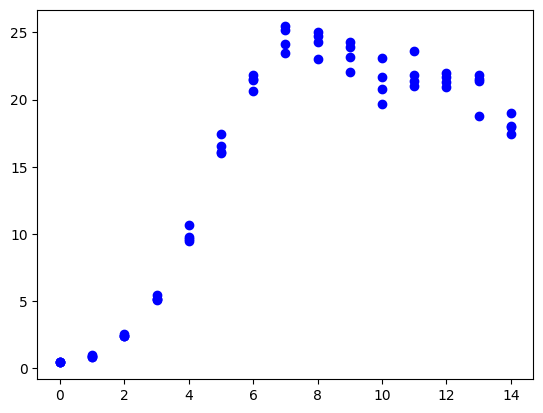

In [144]:
plt.plot(df_wuxi_offline["Day"], df_wuxi_offline["VCC"],"bo")

In [129]:
batch_grouped = df_wuxi_offline.groupby("Batch", group_keys=False)
rate_dict = {}
rate_data = []
for _, group in batch_grouped:
    linearized_vcc = []
    for index in range(len(group["VCC"])-1):
        linearized_data = np.log(group["VCC"].iloc[index+1]/group["VCC"].iloc[index])
        linearized_vcc.append(linearized_data)
    linearized_vcc.append(0)
    group["Linearized"] = linearized_vcc
    rate_data.append(group)
rate_data = pd.concat(rate_data)
rate_data.head()

,Datetime,Batch,Day,VCC,Glucose,Linearized
0,2022-11-18 11:42:20,AR22-092-001,0,0.43,5.87,0.645519
1,2022-11-19 07:04:39,AR22-092-001,1,0.82,5.53,1.118734
2,2022-11-20 09:00:16,AR22-092-001,2,2.51,4.80,0.705029
3,2022-11-21 06:09:21,AR22-092-001,3,5.08,3.61,0.743997
4,2022-11-22 06:34:45,AR22-092-001,4,10.69,4.05,0.435868


array([ 2.08502101e-04,  5.28365806e-03, -1.93946708e-01,  1.11692487e+00])

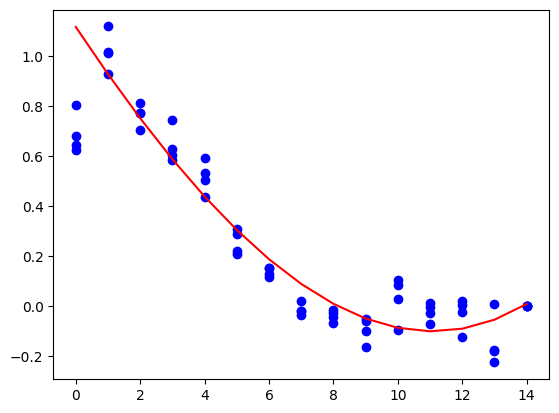

In [180]:
averaged_rates = rate_data.groupby("Day")["Linearized"].mean()
averaged_rates[0] = averaged_rates[1]
x = np.arange(0,len(averaged_rates),1)
rate_fit = np.polyfit(x, np.array(averaged_rates), deg=3)
plt.plot(rate_data["Day"], rate_data["Linearized"], "bo")
plt.plot(x, np.polyval(rate_fit,x),"r")
rate_fit

#### Wuxi Glucose Consumption based on Excel Polyfit

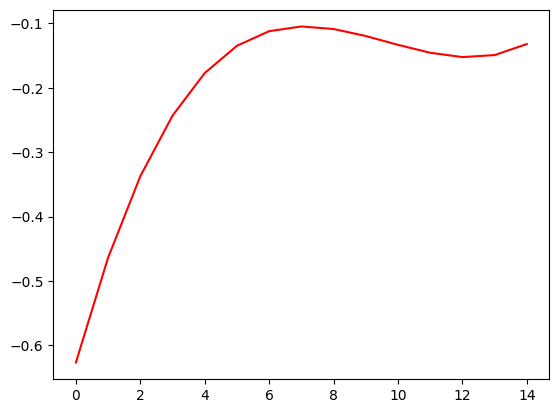

In [146]:
glcCSR = np.array([0.0007, -0.0203, 0.1823, -0.6264])
plt.plot(x, np.polyval(glcCSR,x),"r")

# PVRIG Process 1 Kalman Filter (MR23-008)

#### Mechanistic Models for Process 1

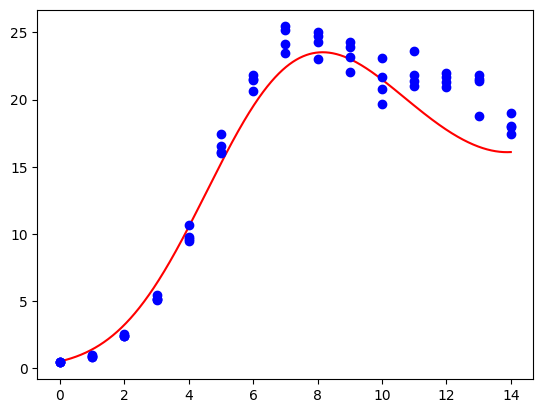

In [186]:
zs=np.array(df_wuxi_online["710-Raman-Glucose"])
x2 = np.linspace(0, 14, len(zs[1:]))
growth_rate = np.array([ 2.08502101e-04,  5.28365806e-03, -1.93946708e-01,  1.11692487e+00])
VCC = []
for count, i in enumerate(x2):
    if i == 0:
        xv = ivcc
        VCC.append(xv)
    else:
        xv = VCC[count-1]*np.exp((i - x2[count-1])*np.polyval(growth_rate,x2[count-1]))
        VCC.append(xv)
plt.plot(x2,VCC,"r-", markersize=1.2)
plt.plot(df_wuxi_offline["Day"],df_wuxi_offline["VCC"],"bo")
# 710-Raman-Glucose
# 710-FeedA-Total
# 710-Glucose-Total

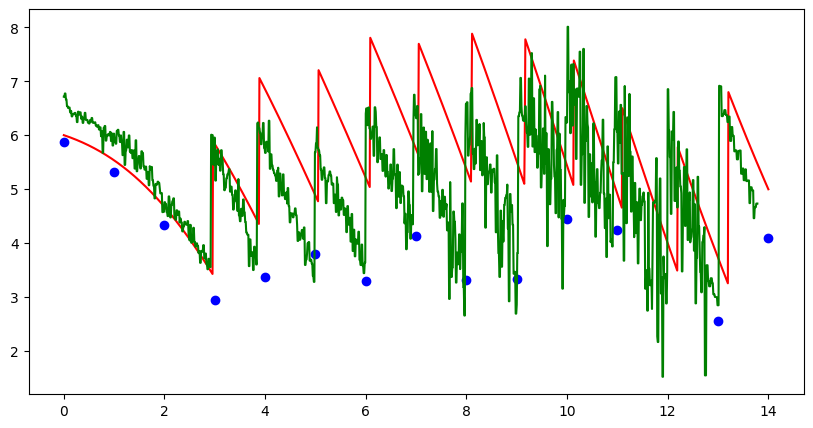

In [201]:
GLC = []
Vol = []
glc0 = 6
glcCSR = np.array([0.0007, -0.0203, 0.1823, -0.6264])
feed_conc = 80
gluc_conc = 400
Volume = 1800
u=np.array(df_wuxi_online[["710-FeedA-Total","710-Glucose-Total"]])
for count, i in enumerate(x2):
    if i == 0:
        glc = glc0
        Vol.append(Volume)
        GLC.append(glc)
    else:
        # glcCSR = np.polyval(np.array([-0.0048,0.0638,-0.2299]),x2[count])
        glc = (GLC[count-1] - ((-np.polyval(glcCSR,x2[count-1]))*((VCC[count]+VCC[count-1])/2)*(x2[count]-x2[count-1]))) + ((u[count][0]-u[count-1][0])*feed_conc + (u[count][1]-u[count-1][1])*gluc_conc)/Vol[count-1]
        new_vol = Vol[count-1] + (u[count][0]-u[count-1][0]) + (u[count][1]-u[count-1][1]) - .15
        Vol.append(new_vol)
        GLC.append(glc)

fig = plt.figure(figsize=(10,5))
plt.plot(x2,GLC,"r-", markersize=1.2)
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR["Gluc-710"],"bo")
plt.plot(df_wuxi_online["Day"],df_wuxi_online["710-Raman-Glucose"],"g-")
# plt.plot(x2,VCC,"b-", markersize=1.2)

In [203]:
feed_conc = 80
gluc_conc = 400
growth_rate = np.array([ 2.08502101e-04,  5.28365806e-03, -1.93946708e-01,  1.11692487e+00])
glcCSR = np.array([0.0007, -0.0203, 0.1823, -0.6264])

def a1(t1, t2, growth_rate):
    return np.exp((t1-t2)*np.polyval(growth_rate,t2))

def a2(t1, t2, growth_rate, glcCSR):
    return np.polyval(glcCSR, t1)*(t1-t2)*a1(t1,t2,growth_rate)

def b1(volume):
    return feed_conc/volume

def b2(volume):
    return gluc_conc/volume

Text(0.5, 1.0, 'DR22-019 Glucose Kalman Filter')

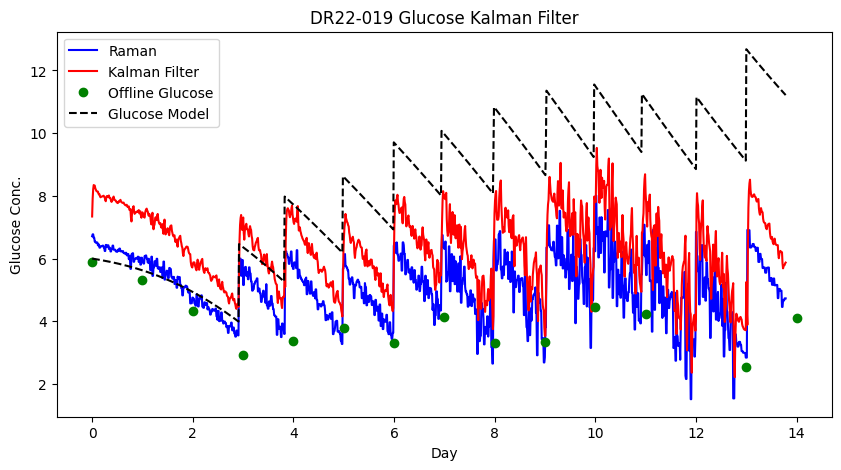

In [217]:
kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=2)
kf.x = np.array([0.4, 6])
kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=1)
kf.H = np.array([[0,.8]])
kf.P = np.diag([2., 1.])
kf.R = np.array([[1]])

u=np.array(df_wuxi_online[["710-FeedA-Daily","710-Glucose-Daily"]])
zs=np.array(df_wuxi_online["710-Raman-Glucose"])
volume=Vol

model_x = []
xs = []

time = np.linspace(0, df_wuxi_online["Day"].max(), len(zs[1:]))

for count, value in enumerate(time):
    if count == 0:
        model_x.append(kf.x)
    else:
        kf.F = np.array([[a1(value, time[count-1], growth_rate), 0],
                         [a2(value, time[count-1], growth_rate, glcCSR), 1]]) # type: ignore
        kf.B = np.array([[0, 0],
                         [b1(volume[count-1]), b2(volume[count-1])]])
        new_x = np.dot(kf.F, model_x[count-1]) + np.dot(kf.B, u[count-1])
        model_x.append(new_x)
    kf.predict(u[count-1])
    kf.update(zs[count])
    xs.append(kf.x)

fig = plt.figure(figsize=(10,5))
plt.plot(time,zs[1:],"b-", label="Raman")
plt.plot(time,np.array(xs)[:,1], "r-",label="Kalman Filter")
plt.plot(df_wuxi_offline_MR["Day"],df_wuxi_offline_MR["Gluc-710"],"go", label="Offline Glucose")
plt.plot(time,np.array(model_x)[:,1],"k--", label="Glucose Model")
# plt.plot(x3,np.array(model_x)[:,0],"k-", label="VCC Model")

plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="upper left")
plt.title("DR22-019 Glucose Kalman Filter")

# PVRIG Process 2 Kalaman Filter (DR22-019)

#### Mechanistic Model for Kalman Filter

In [85]:
zs=np.array(dcs_data["GLUCOSE"])
x2 = np.linspace(0, 13, len(zs[1:]))
growth_rate = np.array([-0.0010862, 0.02961814, -0.24371154, 0.49726371])
ivcc = 28
VCC = []
for count, i in enumerate(x2):
    if i == 0:
        xv = ivcc
        VCC.append(xv)
    else:
        xv = VCC[count-1]*np.exp((i - x2[count-1])*np.polyval(growth_rate,x2[count-1]))
        VCC.append(xv)
# plt.plot(x2,VCC,"ro-", markersize=1.2)

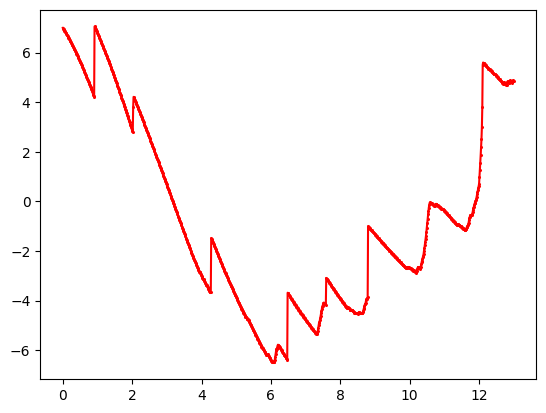

In [86]:
GLC = []
glc0 = 7
glcCSR = .13
feed_conc = 200
gluc_conc = 400
u=np.array(dcs_data[["Daily_feed","Daily_glucose","WEIGHT"]])
for count, i in enumerate(x2):
    if i == 0:
        glc = glc0
        GLC.append(glc)
    else:
        # glcCSR = np.polyval(np.array([-0.0048,0.0638,-0.2299]),x2[count])
        glc = (GLC[count-1] - ((glcCSR)*((VCC[count]+VCC[count-1])/2)*(x2[count]-x2[count-1]))) + (u[count-1][0]*feed_conc + u[count-1][1]*gluc_conc)/u[count-1][2]
        GLC.append(glc)

plt.plot(x2,GLC,"ro-", markersize=1.2)
# plt.plot(x2,VCC,"b-", markersize=1.2)

### Running the Kalman Filter

In [336]:
kf.F = np.array([[-2.51E+02, 2.76E+02],
            [2.59E+02, -3.95E+02]])
kf.B = np.array([[1.06E+02, 1.33E+02],
            [-2.04E+01, -1.60E+02]])

In [ ]:
kf.F = np.array([[0.358, 0.571],
            [0.0241, 0.532]])
kf.B = np.array([[0.49, 0.107],
            [-0.0825, 0.307]])

In [ ]:
kf.F = np.array([[0.358, 0],
                 [0.0241, 0]])
kf.B = np.array([[0.49, 0.107],
                 [-0.0825, 0.307]])

In [99]:
feed_conc = 300
gluc_conc = 400
growth_rate = np.array([-0.0010862, 0.02961814, -0.24371154, 0.49726371])
growth_rate = np.array([ 0.01006653, -0.1535569 ,  0.42557448])
growth_rate = np.array([-0.00080548,  0.02526782, -0.24526846,  0.60174952])

def a1(t1, t2, growth_rate):
    return np.exp((t1-t2)*np.polyval(growth_rate,t2))

def a2(t1, t2, growth_rate, glcCSR):
    return glcCSR*(t1-t2)*a1(t1,t2,growth_rate)

def b1(volume):
    return feed_conc/volume

def b2(volume):
    return gluc_conc/volume

In [100]:
glcCSR_list = [
    [0.652280093,	-0.337678166],
    [1.658703704,	-0.105456367],
    [2.649108796,	-0.067130421],
    [3.669074074,	-0.153762107],
    [4.663877315,	-0.058693773],
    [5.670497685,	-0.189537182],
    [6.661319444,	-0.116265588],
    [7.658368056,	-0.232753032],
    [8.678819444,	-0.048579287],
    [9.647361111,	-0.223745937],
    [10.65701389,	-0.613310361],
]

In [107]:
min(glcCSR_list, key=lambda x:abs(x[0]-5.))[1]

-0.058693773

Text(0.5, 1.0, 'DR22-019 Glucose Kalman Filter')

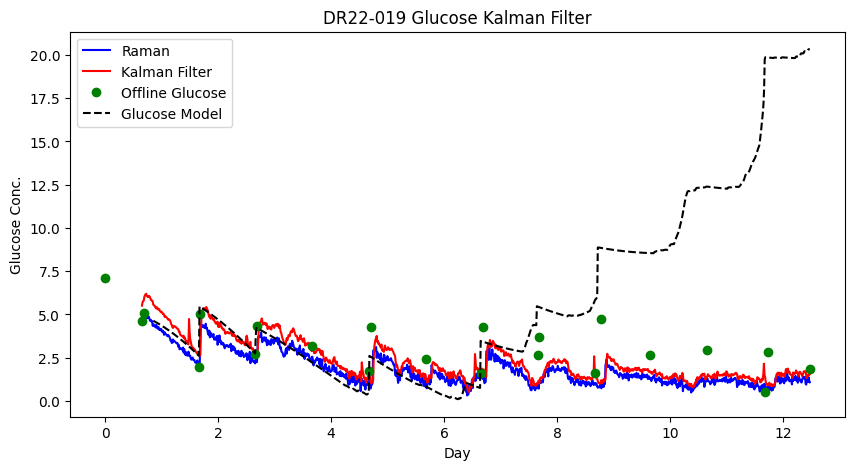

In [112]:
kf = KalmanFilter(dim_x=2, dim_z=1, dim_u=2)
kf.x = np.array([25, 4.64])
# kf.F = np.array([[ 0.98061347,  0.26555845],
#        [ 0.07541668, -0.15333774]])
# kf.B = np.array([[ 2.35773891,  0.42338116],
#        [-6.71691603,  4.73935914]])
kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=1)
kf.H = np.array([[0,.8]])
kf.P = np.diag([2., 1.])
kf.R = np.array([[1]])

u=np.array(dcs_data[["Daily_feed","Daily_glucose"]])
zs=np.array(dcs_data["GLUCOSE"])
volume=np.array(dcs_data["WEIGHT"])

model_x = []
xs = []

time = np.linspace(0.65, offline_data["Day"].max(), len(zs[1:])) # the data doesn't start at 0 but rather 0.66 days

for count, value in enumerate(time):
    if count == 0:
        model_x.append(kf.x)
    else:
        glcCSR = min(glcCSR_list, key=lambda x:abs(x[0]-time[count]))[1]
        glcCSR = -.16
        kf.F = np.array([[a1(value, time[count-1], growth_rate), 0],
                         [a2(value, time[count-1], growth_rate, glcCSR), 1]]) # type: ignore
#
        kf.B = np.array([[0, 0],
                         [b1(volume[count-1]), b2(volume[count-1])]])
#
        new_x = np.dot(kf.F, model_x[count-1]) + np.dot(kf.B, u[count-1])
        model_x.append(new_x)
    kf.predict(u[count-1])
    kf.update(zs[count])
    xs.append(kf.x)

x2 = np.linspace(0.65, offline_data["Day"].max(), len(zs[1:]))
x3 = np.linspace(0.85, offline_data["Day"].max(), len(u[1:]))
fig = plt.figure(figsize=(10,5))

plt.plot(x2,zs[1:],"b-", label="Raman")
plt.plot(x2,np.array(xs)[:,1], "r-",label="Kalman Filter")
plt.plot(offline_data["Day"],offline_data["Gluc"],"go", label="Offline Glucose")
plt.plot(x3,np.array(model_x)[:,1],"k--", label="Glucose Model")
# plt.plot(x3,np.array(model_x)[:,0],"k-", label="VCC Model")

plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="upper left")
plt.title("DR22-019 Glucose Kalman Filter")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


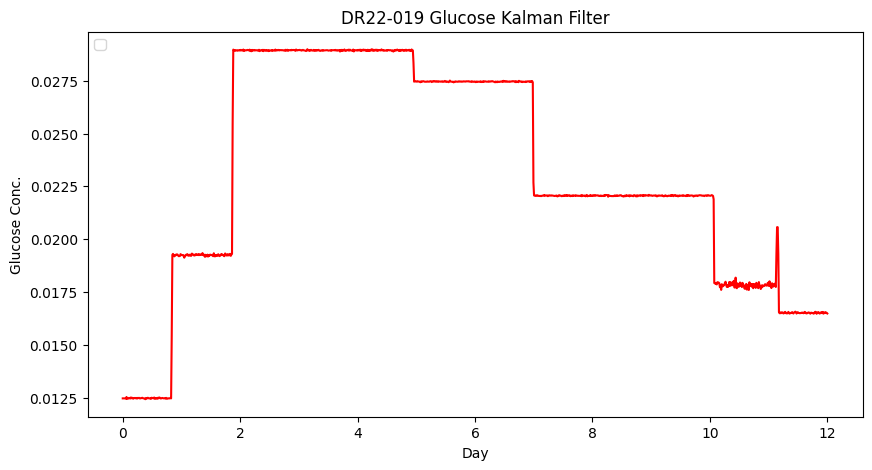

In [81]:
fig = plt.figure(figsize=(10,5))
gluc = np.array(dcs_data["Daily_glucose"])
feed = np.array(dcs_data["Daily_feed"])
x4 = np.linspace(0, 12, len(gluc))
# plt.plot(x4,gluc,"b-")
plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="upper left")
plt.title("DR22-019 Glucose Kalman Filter")
plt.plot(x4,feed,"r-")

In [ ]:
from scipy.interpolate import UnivariateSpline


x2 = np.linspace(0.66, len(offline_data["Gluc"]), len(zs[1:]))
s = UnivariateSpline(x, offline_data["Gluc"]*0.144300, k=3, s=0.0005)
fig = plt.figure(figsize=(10,5))

# plt.plot(dcs_data["Datetime"][1:],s(x2),"o",markersize=2, label="Offline Glucose Data")
plt.plot(dcs_data["Datetime"][1:],zs[1:],"b-", label="Raman Data")
plt.plot(dcs_data["Datetime"][1:],np.array(xs)[:,1], "r-",label="Kalman Filter")
plt.plot(offline_data["Datetime"],offline_data["Gluc"],"go", label="Offline Glucose Data")
# plt.plot(dcs_data["Datetime"][1:],GLC,"g-", markersize=1.2)
plt.plot(dcs_data["Datetime"][1:],np.array(model_x)[:,1],"g-", label="Model Data")

plt.xlabel("Day")
plt.ylabel("Glucose Conc.")
plt.legend(loc="upper center")
plt.title("DR22-019 Glucose Kalman Filter")

In [202]:
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

def gluc_filter(x, F, B, H, P, R, Q=0., dt=1.0):
    """ Returns a KalmanFilter which implements a
    constant velocity model for a state [x dx].T
    """
    
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = x                # location and velocity
    kf.F = F                # state transition matrix
    kf.B = B                # Input transition matrix
    kf.H = H                # Measurement function
    kf.R = R                # measurement uncertainty
    if np.isscalar(P):
        kf.P = P            # covariance matrix 
    else:
        kf.P[:] = P         # [:] makes deep copy
    if np.isscalar(Q):
        kf.Q = Q_discrete_white_noise(dim=2, dt=dt, var=Q)
    else:
        kf.Q[:] = Q
    return kf

In [209]:
def run( u, kf, dt, zs, do_plot=True, **kwargs):
    """
    track is the actual glucose measurement, zs are the 
    corresponding measurements.
    """

    # Simulate dog if no data provided. 
    if zs is None:
        pass
        # track, zs = compute_dog_data(R, Q, count)

    # run the kalman filter and store the results
    xs, cov = [], []
    for count, z in enumerate(zs):
        kf.predict(x, P, F, Q)
        kf.update(x, P, z)
        xs.append(kf.x)
        cov.append(kf.P)

    xs, cov = np.array(xs), np.array(cov)
    x_plot = np.arange(0, len(zs), dt)
    if do_plot:
        plt.plot(x_plot*.25/24, xs, "ro", markersize=1)
        # plt.plot(x_plot*.25/24, u, "b-")
        plt.plot(x_plot*.25/24, zs, "b-")
    return xs, cov

In [352]:
kf = gluc_filter(x, F, B, H, P, R, Q=0., dt=1.0)

Ms, Ps = run(
    kf=kf,
    dt=1,
    u=np.array(dcs_data[["Feed_Normalized","Glucose_feed_Normalized"]]),
    zs=np.array(dcs_data["Glucose_Normalized"]),
    count=len(dcs_data["Glucose_Normalized"]),
)

ValueError: z must be convertible to shape (1, 1)

#### Determining Glucose Consumption Rate

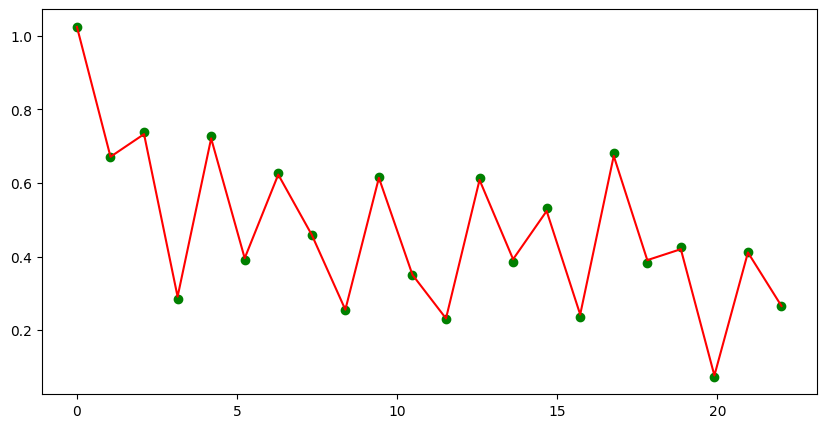

In [361]:
from scipy.interpolate import UnivariateSpline
x = np.linspace(0, len(offline_data["Gluc"]), 22)
# fit spline
s = UnivariateSpline(x, offline_data["Gluc"]*0.144300, k=3, s=0.0005)
fig = plt.figure(figsize=(10,5))
plt.plot(x,offline_data["Gluc"]*0.144300,"go", label="Offline Glucose Data")
plt.plot(x,s(x),"r-", label="Offline Glucose Data")

         Current function value: 129.071802
         Iterations: 0
         Function evaluations: 997
         Gradient evaluations: 110
Optimal F: [[ 0.98061347  0.26555845]
 [ 0.07541668 -0.15333774]]
Optimal B: [[ 2.35773891  0.42338116]
 [-6.71691603  4.73935914]]


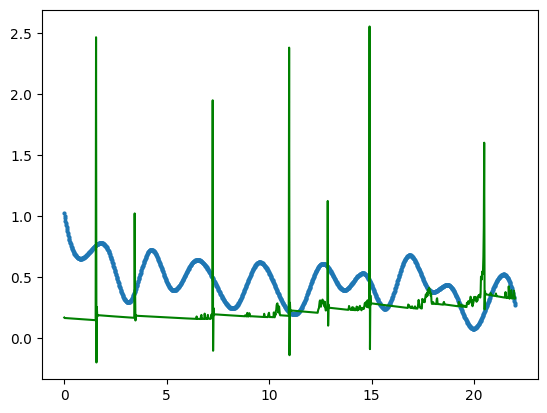

In [435]:
from scipy.optimize import minimize

x2 = np.linspace(0, len(offline_data["Gluc"]), len(zs[1:]))
s = UnivariateSpline(x, offline_data["Gluc"]*0.144300, k=3, s=0.0005)
u=np.array(dcs_data[["Feed_Normalized","Glucose_feed_Normalized"]])
zs=np.array(dcs_data["Glucose_Normalized"])
f_mat = np.array([[ 0.98061347,  0.26555845],
       [ 0.07541668, -0.15333774]])
b_mat = np.array([[ 2.35773891,  0.42338116],
       [-6.71691603,  4.73935914]])
mat = np.vstack([f_mat.reshape(-1,1),b_mat.reshape(-1,1)])

def optimizer(mat):
    f_mat = mat[:4].reshape(2,2)
    b_mat = mat[4:].reshape(2,2)
    model_x = []
    for count in range(len(zs)-1):
        if count == 0:
            model_x.append(kf.x)
        else:
            new_x = np.dot(f_mat, model_x[count-1]) + np.dot(b_mat, u[count-1])
            model_x.append(new_x)
    return ((s(x2) - np.array(model_x)[:,1]) ** 2).sum()


res = minimize(
    optimizer,
    mat,
    options={'gtol': 1e-4, 'disp': True},
)
opt_matrix = res.x
f_mat_opt = opt_matrix[:4].reshape(2,2)
b_mat_opt = opt_matrix[4:].reshape(2,2)
print(f"Optimal F: {f_mat_opt}")
print(f"Optimal B: {b_mat_opt}")

model_x = []
for count in range(len(zs)-1):
    if count == 0:
        model_x.append(kf.x)
    else:
        new_x = np.dot(f_mat_opt, model_x[count-1]) + np.dot(b_mat_opt, u[count-1])
        model_x.append(new_x)

plt.plot(x2,s(x2),"o",markersize=2, label="Offline Glucose Data")
plt.plot(x2,np.array(model_x)[:,1],"g-", label="Model Data")